<a href="https://colab.research.google.com/github/ssamatyya1/news_classification/blob/main/iod3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Парсинг новостей
def parse_bfm_news(pages=10):
    base_url = "https://www.bfm.ru"
    articles = []

    for page in tqdm(range(1, pages + 1)):
        url = f"{base_url}/news?type=news&page={page}"
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        if response.status_code != 200:
            print(f" Ошибка при загрузке страницы {url}. Код состояния: {response.status_code}")
        soup = BeautifulSoup(response.content, "html.parser")

        for li in soup.find_all("li"):
            title_tag = li.find("a", class_="title-link")
            # url = f"{base_url}/{title_tag['href']}"
            rubric_tag = li.find("a", class_="rubrik")

            if title_tag and rubric_tag:
                url = f"{base_url}{title_tag['href']}"
                response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
                if response.status_code != 200:
                  print(f" Ошибка при загрузке страницы {url}. Код состояния: {response.status_code}")
                soup = BeautifulSoup(response.content, "html.parser")
                text = soup.find_all("div", class_="current-article")[0].get_text()
                title = title_tag.text.strip()
                category = rubric_tag.text.strip()
                articles.append({
                    "url": url,
                    "title": title,
                    "category": category,
                    "text": text
                })

    return pd.DataFrame(articles)

df = parse_bfm_news(pages=100)
print(f"Загружено {len(df)} новостей.")
print(df.head())

100%|██████████| 100/100 [19:02<00:00, 11.43s/it]

Загружено 1195 новостей.
                              url  \
0  https://www.bfm.ru/news/573786   
1  https://www.bfm.ru/news/573783   
2  https://www.bfm.ru/news/573784   
3  https://www.bfm.ru/news/573737   
4  https://www.bfm.ru/news/573782   

                                               title  category  \
0  Житель Сахалина выиграл миллиард в «Русское лото»  Общество   
1  Минздрав США отменил гранты для Гарварда на $6...  Политика   
2  Экс-глава «Роскосмоса» Борисов назначен сенато...  Политика   
3  Алюминиевая ассоциация: в России начали строит...  Компании   
4    Российский хоккеист НХЛ задержан в США за драку  Общество   

                                                text  
0  Эти деньги он планирует потратить на недвижимо...  
1  Вуз обвинили в антисемитизме и дискриминации  ...  
2  После ухода из «Роскосмоса» Борисов занимал до...  
3  Среди основных достоинств материала эксперты в...  
4  В клубе «Вашингтон» сообщили, что выясняют все...  


Преобработка текста

In [ ]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stopwords_ru = stopwords.words("russian")

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'[^\w\s]', '', text.lower())
    words = text.split()
    words = [word for word in words if word not in stopwords_ru]
    return " ".join(words)

df["text_clear"] = df["text"].apply(preprocess_text)
df = df[df["text_clear"].str.strip() != ""]
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,url,title,category,text,text_clear
0,https://www.bfm.ru/news/573786,Житель Сахалина выиграл миллиард в «Русское лото»,Общество,Эти деньги он планирует потратить на недвижимо...,деньги планирует потратить недвижимость отправ...
1,https://www.bfm.ru/news/573783,Минздрав США отменил гранты для Гарварда на $6...,Политика,Вуз обвинили в антисемитизме и дискриминации ...,вуз обвинили антисемитизме дискриминации гарва...
2,https://www.bfm.ru/news/573784,Экс-глава «Роскосмоса» Борисов назначен сенато...,Политика,После ухода из «Роскосмоса» Борисов занимал до...,ухода роскосмоса борисов занимал должность спе...
3,https://www.bfm.ru/news/573737,Алюминиевая ассоциация: в России начали строит...,Компании,Среди основных достоинств материала эксперты в...,среди основных достоинств материала эксперты в...
4,https://www.bfm.ru/news/573782,Российский хоккеист НХЛ задержан в США за драку,Общество,"В клубе «Вашингтон» сообщили, что выясняют все...",клубе вашингтон сообщили выясняют детали проис...
...,...,...,...,...,...
1190,https://www.bfm.ru/news/571925,Срок объявленного Россией пасхального перемири...,Политика,Режим действовал на протяжении 30 часовВ полно...,режим действовал протяжении 30 часовв полночь ...
1191,https://www.bfm.ru/news/571915,SCMP: Китай провел испытания неядерной водород...,Технологии,В ней использован гидрид магнияКитай успешно и...,использован гидрид магниякитай успешно испытал...
1192,https://www.bfm.ru/news/571916,Исследование: перенесшие COVID-19 болеют вдвое...,Общество,"Американские ученые пришли к выводу, что у пер...",американские ученые пришли выводу переболевших...
1193,https://www.bfm.ru/news/571917,США перебросили в Японию еще два бомбардировщи...,Политика,Участие первых двух таких самолетов в совместн...,участие первых двух таких самолетов совместных...


Векторизация текста

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["text_clear"])

Оценка количества кластеров

Text(0, 0.5, 'Inertia')

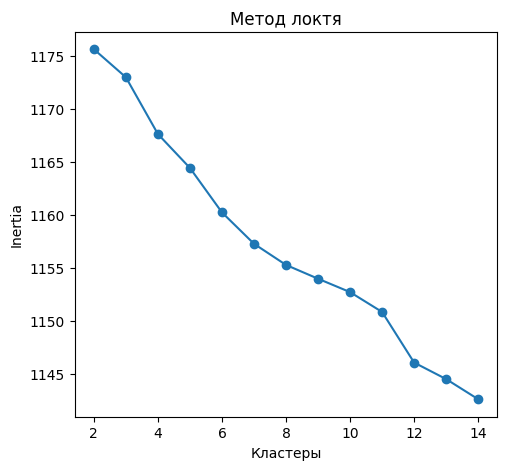

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)

# Метод локтя
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 15), inertia, marker='o')
plt.title('Метод локтя')
plt.xlabel('Кластеры')
plt.ylabel('Inertia')


Кластеризация

In [ ]:
# Выбираем 11 кластеров на основе метода локтя
kmeans = KMeans(n_clusters=11, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

from sklearn.metrics import rand_score

true_labels = df["category"].astype("category").cat.codes
rand_score_value = rand_score(true_labels, df["cluster"])

print(f"RAND Index: {rand_score_value:.3f}")

RAND Index: 0.649


Обучение классификатора на одном из кластеров

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
df["target"] = (df["cluster"] == 0).astype(int)

#  Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, df["target"], test_size=0.3, random_state=42, stratify=df["target"])

# Обучение логистической регрессии
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Предсказание и оценка
y_pred = clf.predict(X_test)

print("F1-score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

F1-score: 0.8125
Confusion Matrix:
 [[340   0]
 [  6  13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       340
           1       1.00      0.68      0.81        19

    accuracy                           0.98       359
   macro avg       0.99      0.84      0.90       359
weighted avg       0.98      0.98      0.98       359

